# 下一课：CartPole + Dueling DQN

上一课我们学了 `Double DQN`，主要是在 target 的计算方式上做改进。

这一课我们学习另一条非常经典的改进路线：`Dueling DQN`。

它不改 target 的公式，而是改神经网络的结构。

这一课你会学到：
- 为什么普通 Q 网络有时学得不够高效
- 什么是 `Value` 和 `Advantage`
- Dueling DQN 是怎么把 Q 值拆开来学的


## 1. 为什么还要改网络结构

普通 DQN 的网络是直接输出每个动作的 Q 值：

`Q(s, left), Q(s, right), ...`

但有些状态下，真正重要的信息其实分成两部分：

- 这个状态本身好不好
- 某个动作相对其他动作到底好多少

举个直觉例子：

在某些状态里，无论你左右推，结果都差不多，那动作之间的差别其实没那么关键；
更关键的是“这个状态整体就不错”或者“这个状态整体就很危险”。

Dueling DQN 就是把这两部分拆开来学。


## 2. Dueling DQN 的核心思想

Dueling DQN 不直接让网络只输出 Q 值，而是拆成两个分支：

- `V(s)`：这个状态本身有多好，叫做状态价值 `Value`
- `A(s, a)`：某个动作比平均动作好多少，叫做动作优势 `Advantage`

最后再把它们组合回 Q 值：

$Q(s, a) = V(s) + A(s, a) - mean(A(s, \cdot))$

这里减掉 `mean(A)` 是为了让分解更稳定，避免 value 和 advantage 之间相互抢解释权。


In [1]:
import random
import warnings
from collections import deque

import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

plt.style.use('seaborn-v0_8-whitegrid')
np.set_printoptions(precision=3, suppress=True)

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)


In [2]:
def pick_device():
    if torch.cuda.is_available():
        try:
            _ = torch.zeros(1, device='cuda')
            return torch.device('cuda')
        except Exception as e:
            warnings.warn(f'检测到 CUDA，但当前环境无法真正使用 GPU，已回退到 CPU。原因: {e}')
    return torch.device('cpu')


device = pick_device()
print('当前设备:', device)
if torch.cuda.is_available():
    print('检测到 CUDA 设备:', torch.cuda.get_device_name(0))


当前设备: cuda
检测到 CUDA 设备: NVIDIA GeForce RTX 5090


In [3]:
env = gym.make('CartPole-v1')
state, info = env.reset(seed=42)
print('初始状态:', state)
print('状态维度:', env.observation_space.shape[0])
print('动作数量:', env.action_space.n)


初始状态: [ 0.027 -0.006  0.036  0.02 ]
状态维度: 4
动作数量: 2


In [4]:
class ReplayBuffer:
    def __init__(self, capacity=50000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return np.array(states), actions, rewards, np.array(next_states), dones

    def __len__(self):
        return len(self.buffer)


def to_tensor(x, device):
    return torch.tensor(x, dtype=torch.float32, device=device)


## 3. Dueling 网络结构

这部分是整节课的核心。

网络先经过一段共享特征提取层，然后分成两个分支：

- `value_stream`：输出一个标量 `V(s)`
- `advantage_stream`：输出每个动作的 `A(s, a)`

最后再组合成 Q 值。


In [5]:
class DuelingQNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=128):
        super().__init__()

        self.feature = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU()
        )

        # Value 分支：只输出一个数，表示状态本身有多好
        self.value_stream = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

        # Advantage 分支：输出每个动作的相对优势
        self.advantage_stream = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim)
        )

    def forward(self, x):
        features = self.feature(x)
        value = self.value_stream(features)
        advantage = self.advantage_stream(features)

        # 组合回 Q 值。
        # 减去 advantage 的均值是经典做法，可以避免 value 和 advantage 分工混乱。
        q_values = value + advantage - advantage.mean(dim=1, keepdim=True)
        return q_values


## 4. 训练 Dueling DQN

这节课我们先不把 `Double DQN` 也一起揉进来，避免一次塞太多。

所以这里的重点只放在：
- 网络结构改成 dueling
- 其他训练流程仍然保持标准 DQN 形式

这样你能更清楚地看到：

**这节课的本质变化是网络结构，不是 target 公式。**


In [6]:
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

q_net = DuelingQNetwork(state_dim, action_dim, hidden_dim=128).to(device)
target_net = DuelingQNetwork(state_dim, action_dim, hidden_dim=128).to(device)
target_net.load_state_dict(q_net.state_dict())
target_net.eval()

optimizer = optim.Adam(q_net.parameters(), lr=5e-4)
criterion = nn.SmoothL1Loss()
replay_buffer = ReplayBuffer(capacity=50000)

gamma = 0.99
epsilon = 1.0
epsilon_decay = 0.997
epsilon_min = 0.02
episodes = 300
max_steps = 500
batch_size = 128
target_update_freq = 20
train_start = 1000

episode_rewards = []
loss_history = []
buffer_sizes = []

for episode in range(episodes):
    state, info = env.reset()
    total_reward = 0.0

    for step in range(max_steps):
        state_tensor = to_tensor(state, device).unsqueeze(0)

        with torch.no_grad():
            q_values = q_net(state_tensor)

        if random.random() < epsilon:
            action = env.action_space.sample()
        else:
            action = int(torch.argmax(q_values, dim=1).item())

        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        replay_buffer.push(state, action, reward, next_state, done)
        buffer_sizes.append(len(replay_buffer))

        state = next_state
        total_reward += reward

        if len(replay_buffer) >= train_start:
            states, actions, rewards, next_states, dones = replay_buffer.sample(batch_size)

            states_tensor = to_tensor(states, device)
            next_states_tensor = to_tensor(next_states, device)
            actions_tensor = torch.tensor(actions, dtype=torch.long, device=device).unsqueeze(1)
            rewards_tensor = torch.tensor(rewards, dtype=torch.float32, device=device)
            dones_tensor = torch.tensor(dones, dtype=torch.float32, device=device)

            current_q_values = q_net(states_tensor)
            chosen_q_values = current_q_values.gather(1, actions_tensor).squeeze(1)

            with torch.no_grad():
                next_q_values = target_net(next_states_tensor)
                max_next_q_values = next_q_values.max(dim=1).values
                targets = rewards_tensor + gamma * max_next_q_values * (1 - dones_tensor)

            loss = criterion(chosen_q_values, targets)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(q_net.parameters(), max_norm=10.0)
            optimizer.step()

            loss_history.append(float(loss.item()))

        if done:
            break

    episode_rewards.append(total_reward)
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    if (episode + 1) % target_update_freq == 0:
        target_net.load_state_dict(q_net.state_dict())

print('训练完成。')
print('最后 20 轮平均 reward:', round(float(np.mean(episode_rewards[-20:])), 2))


训练完成。
最后 20 轮平均 reward: 63.0


C:\Users\80740\AppData\Local\Temp\ipykernel_25120\3899257459.py:23: UserWarning: Glyph 27599 (\N{CJK UNIFIED IDEOGRAPH-6BCF}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\80740\AppData\Local\Temp\ipykernel_25120\3899257459.py:23: UserWarning: Glyph 36718 (\N{CJK UNIFIED IDEOGRAPH-8F6E}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\80740\AppData\Local\Temp\ipykernel_25120\3899257459.py:23: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\80740\AppData\Local\Temp\ipykernel_25120\3899257459.py:23: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\80740\AppData\Local\Temp\ipykernel_25120\3899257459.py:23: UserWarning: Glyph 25439 (\N{CJK UNIFIED IDEOGRAPH-635F}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\80740\AppData\Local\Temp\ipykernel_25120\3899257459.py:23: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931})

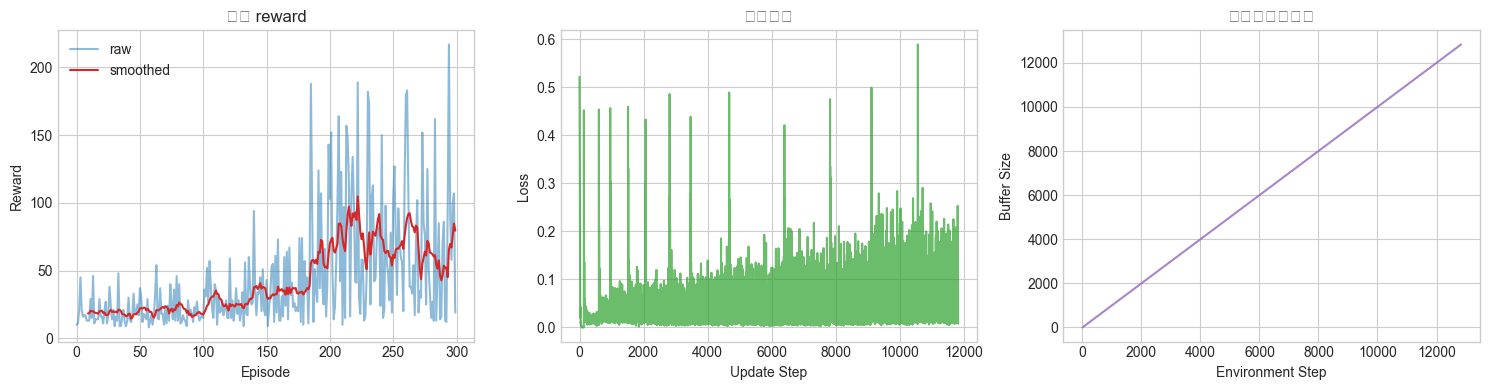

In [7]:
window = 10
smoothed_rewards = np.convolve(episode_rewards, np.ones(window) / window, mode='valid')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(episode_rewards, color='#1f77b4', alpha=0.5, label='raw')
axes[0].plot(range(window - 1, len(episode_rewards)), smoothed_rewards, color='#d62728', label='smoothed')
axes[0].set_title('每轮 reward')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Reward')
axes[0].legend()

axes[1].plot(loss_history, color='#2ca02c', alpha=0.7)
axes[1].set_title('训练损失')
axes[1].set_xlabel('Update Step')
axes[1].set_ylabel('Loss')

axes[2].plot(buffer_sizes, color='#9467bd', alpha=0.8)
axes[2].set_title('经验池大小变化')
axes[2].set_xlabel('Environment Step')
axes[2].set_ylabel('Buffer Size')

plt.tight_layout()
plt.show()


## 5. 多次测试平均表现

和前几课一样，我们测 5 次并看平均 reward，这样结果更稳定。


In [8]:
test_env = gym.make('CartPole-v1')
test_rewards = []

q_net.eval()
with torch.no_grad():
    for episode_idx in range(5):
        state, info = test_env.reset(seed=123 + episode_idx)
        test_reward = 0.0
        for step in range(500):
            state_tensor = to_tensor(state, device).unsqueeze(0)
            action = int(torch.argmax(q_net(state_tensor), dim=1).item())
            state, reward, terminated, truncated, info = test_env.step(action)
            test_reward += reward
            if terminated or truncated:
                break
        test_rewards.append(test_reward)

print('测试 rewards:', test_rewards)
print('测试平均 reward:', round(float(np.mean(test_rewards)), 2))
test_env.close()


测试 rewards: [121.0, 103.0, 114.0, 116.0, 116.0]
测试平均 reward: 114.0


## 6. 这节课最值得记住的点

如果你想抓住 Dueling DQN 的本质，就记住这句话：

**它不是改 target，而是改网络，让网络把“状态本身好不好”和“动作相对好不好”分开学。**

所以它和 Double DQN 的关注点是不一样的：
- `Double DQN`：主要解决高估问题
- `Dueling DQN`：主要提升价值分解与表示能力


## 7. 下一课最自然学什么

学完这一课后，最自然的下一步通常是：
- `Prioritized Experience Replay`
- 把 `Double DQN + Dueling DQN` 组合起来

如果按学习路线来说，下一课我最推荐你上 `Prioritized Replay`。
